✅ Đã cài đặt và import thư viện xong!

 VUI LÒNG UPLOAD FILE 'TỔNG HỢP ĐIỂM K58KTP.xlsx'


Saving TỔNG HỢP ĐIỂM K58KTP.xlsx to TỔNG HỢP ĐIỂM K58KTP (4).xlsx
 Đã upload file: TỔNG HỢP ĐIỂM K58KTP (4).xlsx
Đã đọc thành công 72 sinh viên
✅ Đã xử lý xong dữ liệu điểm

 Đang phân cụm sinh viên thành 3 nhóm...
Phân cụm hoàn tất!

 KẾT QUẢ PHÂN CỤM:
Loai
Giỏi          45
Yếu           22
Trung bình     5
Name: count, dtype: int64


/tmp/ipykernel_371/1909302126.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Loai', y='Diem_TB', data=du_lieu, palette='Set2')


NameError: name 'ax' is not defined

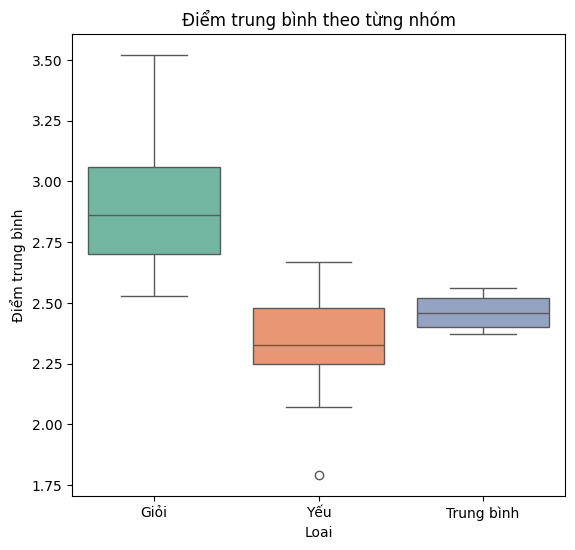

In [5]:

# PHÂN CỤM SINH VIÊN K58
#PHẦN 1: CÀI ĐẶT THƯ VIỆN
# Mục đích: Cài các thư viện cần thiết để chạy chương trình
!pip install pandas scikit-learn matplotlib seaborn openpyxl -q

#  PHẦN 2: KHỞI TẠO CÁC THƯ VIỆN ====================
import pandas as pd          # Dùng để đọc và xử lý file Excel
import numpy as np           # Dùng để tính toán số học
from sklearn.cluster import KMeans          # Thuật toán phân cụm K-Means
from sklearn.preprocessing import StandardScaler  # Chuẩn hóa dữ liệu
import matplotlib.pyplot as plt             # Vẽ biểu đồ
import seaborn as sns                       # Vẽ biểu đồ đẹp hơn
from google.colab import files              # Upload và download file trong Colab

print("Đã cài đặt và import thư viện xong!")

#  PHẦN 3: UPLOAD FILE EXCEL
print("\n VUI LÒNG UPLOAD FILE DU LIEU ")
uploaded = files.upload()                    # Mở hộp thoại upload file

# Lấy tên file vừa upload
file_name = list(uploaded.keys())[0]
print(f" Đã upload file: {file_name}")

# PHẦN 4: ĐỌC DỮ LIỆU TỪ FILE EXCEL
# Đọc file Excel mà không dùng header vì file của bạn có cấu trúc đặc biệt
df = pd.read_excel(file_name, header=None)

# Lấy thông tin sinh viên (MSSV và Họ Tên) từ hàng 1 và 2
thong_tin_sv = df.iloc[1:3, 2:].T           # .T là chuyển vị (transpose)
thong_tin_sv.columns = ['MSSV', 'Ho_Ten']

# Lấy phần điểm số (từ hàng 4 trở đi)
diem = df.iloc[4:, 2:].T
diem.columns = df.iloc[4:, 1].values        # Lấy tên môn học làm tên cột

# Ghép thông tin sinh viên và điểm lại với nhau
du_lieu = pd.concat([thong_tin_sv.reset_index(drop=True),
                     diem.reset_index(drop=True)], axis=1)

print(f"Đã đọc thành công {len(du_lieu)} sinh viên")

# PHẦN 5: XỬ LÝ DỮ LIỆU (LÀM SẠCH)
# Chuyển tất cả điểm sang dạng số (nếu có chữ thì thành NaN)
for cot in du_lieu.columns[2:]:
    du_lieu[cot] = pd.to_numeric(du_lieu[cot], errors='coerce')

# Điền các ô điểm trống (NaN) bằng điểm trung bình của môn đó
du_lieu = du_lieu.fillna(du_lieu.mean(numeric_only=True))

# Tính điểm trung bình của từng sinh viên
du_lieu['Diem_TB'] = du_lieu.iloc[:, 2:].mean(axis=1).round(2)

print("Đã xử lý xong dữ liệu điểm")

# PHẦN 6: PHÂN CỤM BẰNG K-MEANS
print("\n Đang phân cụm sinh viên thành 3 nhóm...")

# Chuẩn bị dữ liệu chỉ lấy cột điểm (bỏ MSSV, Họ tên, Điểm TB)
X = du_lieu.iloc[:, 2:-1]

# Chuẩn hóa dữ liệu (rất quan trọng cho K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Thực hiện phân cụm thành 3 nhóm
kmeans = KMeans(n_clusters=3, random_state=42)
du_lieu['Cum'] = kmeans.fit_predict(X_scaled)

# Đặt tên nhóm cho dễ hiểu (dựa vào điểm trung bình)
cum_order = du_lieu.groupby('Cum')['Diem_TB'].mean().sort_values(ascending=False).index
map_cum = {cum_order[0]: "Giỏi", cum_order[1]: "Trung bình", cum_order[2]: "Yếu"}
du_lieu['Loai'] = du_lieu['Cum'].map(map_cum)

print("Phân cụm hoàn tất!")

# PHẦN 7: XUẤT KẾT QUẢ =
# Lưu kết quả ra file Excel
du_lieu.to_excel('phan_cum_sinh_vien_k58.xlsx', index=False)

# Hiển thị số lượng sinh viên mỗi nhóm
print("\n KẾT QUẢ PHÂN CỤM:")
print(du_lieu['Loai'].value_counts())

#  PHẦN 8: VẼ BIỂU ĐỒ MINH HỌA
plt.figure(figsize=(14, 6))

# Biểu đồ 1: Boxplot điểm trung bình theo nhóm
plt.subplot(1, 2, 1)
sns.boxplot(x='Loai', y='Diem_TB', data=du_lieu, palette='Set2')
plt.title('Điểm trung bình theo từng nhóm')
plt.ylabel('Điểm trung bình')

# Biểu đồ 2: Số lượng sinh viên mỗi nhóm
plt.subplot(1, 2, 2)
du_lieu['Loai'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Số lượng sinh viên mỗi nhóm')
plt.ylabel('Số sinh viên')
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('bieu_do_phan_cum.png')
plt.show()

# PHẦN 9: TẢI FILE VỀ MÁY
files.download('phan_cum_sinh_vien_k58.xlsx')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')